# Example run
This notebook performs an example run reproducing the background in \cite(Staelens+Nelemans)

In [51]:
from lisaastrophysicalbackgrounds.gravitational_wave_background import GravitationalWaveBackground

gwb = GravitationalWaveBackground('config.yaml')

The metallicities of this population are None


In [52]:
gwb.calculate_GWB()

frequencies = gwb.f_vals
omega_gw = gwb.omega_f
num_sources = gwb.N_sources_f

Saving results at /Users/rrondeel/Code/LISA_data_analysis/LISA_Astrophysical_Backgrounds/results


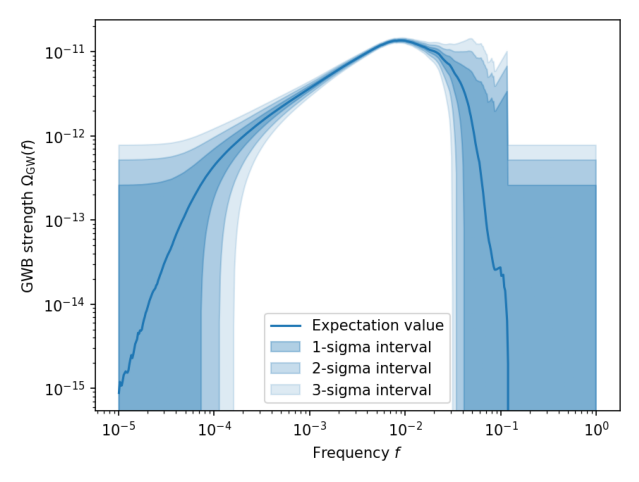

In [53]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Load the image
img = mpimg.imread("./results/GWB_for_mock_catalogue_with_madau_and_dickinson.png")

# 2. Display the image
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis('off')
plt.show()

[]

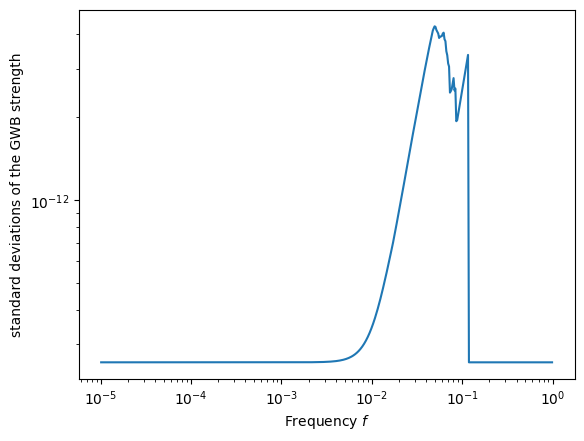

In [54]:
var_f = gwb.var_f
plt.loglog(frequencies, var_f**(0.5))
plt.ylabel(r"standard deviations of the GWB strength")
plt.xlabel(r"Frequency $f$")
plt.plot()

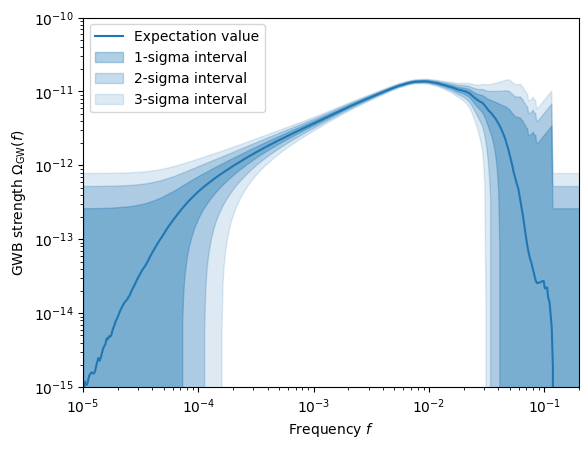

In [55]:
plt.loglog(frequencies, omega_gw, label="Expectation value")
plt.fill_between(frequencies, omega_gw - var_f**(0.5), omega_gw + var_f**(0.5), alpha=0.35, label="1-sigma interval", color="tab:blue")
plt.fill_between(frequencies, omega_gw - 2.0*var_f**(0.5), omega_gw + 2.0*var_f**(0.5), alpha=0.25, label="2-sigma interval", color="tab:blue")
plt.fill_between(frequencies, omega_gw - 3.0*var_f**(0.5), omega_gw + 3.0*var_f**(0.5), alpha=0.15, label="3-sigma interval", color="tab:blue")
plt.ylabel(r"GWB strength $\Omega_{\rm{GW}}(f)$")
plt.xlabel(r"Frequency $f$")
plt.ylim([1e-15, 1e-10])
plt.xlim([1e-5, 2e-1])
plt.legend()
plt.show()

(1, 1e+16)

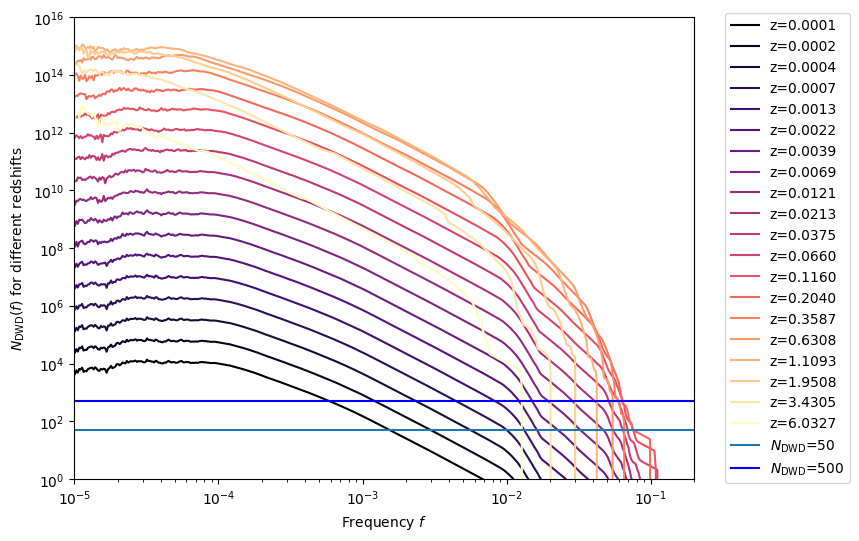

In [66]:
num_syst_fz = gwb.N_sources_fz
num_syst_fz = num_syst_fz.at[num_syst_fz < 0.5].set(0)
z_vals = gwb.cosmology.z_vals

cmap = plt.get_cmap('magma')
import numpy as np
colors = cmap(np.linspace(0, 1, len(z_vals)))


plt.figure(figsize=(8,6))
for i, z in enumerate(z_vals):
    plt.loglog(frequencies, num_syst_fz[:,i], label=f"z={z:.4f}", color=colors[i])
 
plt.axhline(5e1, label=r"$N_{\rm{DWD}}$=50")   
plt.axhline(5e2, label=r"$N_{\rm{DWD}}$=500", c='b')

plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
plt.xlabel(r"Frequency $f$")
plt.ylabel(r"$N_{\rm{DWD}}(f)$ for different redshifts")
plt.xlim([1e-5, 2e-1])
plt.ylim([1, 1e16])